# Feature Selection
* Motivation for Feature Selection
* Methods for Feature Selection
    - Filter Methods
        * Bivariate Filter
        * Multiariate Filter - VIF
    - Subset Selection
        * Best Sebset Selection
        * Forward Selection
        * Backward Selection
        * Stepwise Selection
    - Shrinkage
        * Ridge Regression
        * Lasso (Main)
    - Dimension Reduction
        * Principal Components Analysis (PCA or Principal Components Regression)
        * Partial Least Squares

## Motivation for Feature Selection
* Parsimony is a desirable property for models
    - Predictions from simple (versus complex models) are more stable across samples
    - Simple models are easier to interpret and communicate to stakeholders. 

* As number of predictors increases, the chance of finding correlations among a predictor or a set of predictors increases. Such correlations among predictors called multicollinearity inflates standard errors of coefficients, potentially leading to erroneous conclusions about the relevance of a predictor. 

**Multicollinearity and its Effects**
- The standard error of a coefficient estimates the variability or uncertainty around the coefficient estimate. It is a crucial measure because it informs how precisely the model estimates the unknown parameter.

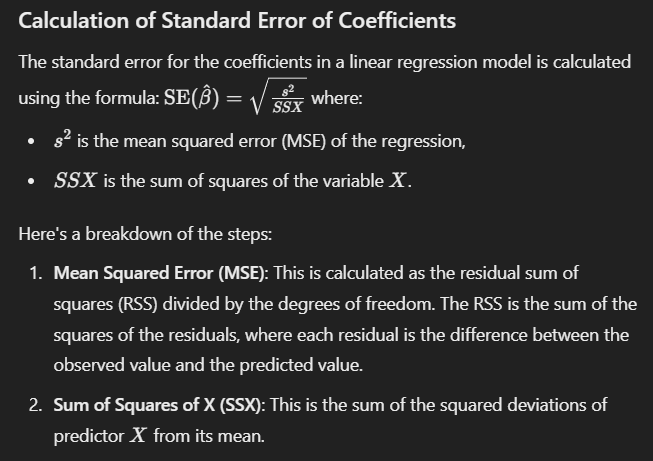

- The standard error of a coefficient provides an estimate of the variability of the coefficient across different samples from the same population. A smaller standard error indicates that the coefficient estimate is more precise or less variable from sample to sample. In statistical testing, the standard error is used to calculate the t-statistic for testing the null hypothesis that the coefficient is equal to zero (i.e., it has no effect).

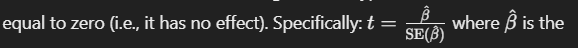

* In cases where p (number of predictors) > n (number of rows of the sample), traditional estimation techniques will not work. 

- When the number of predictors (p) exceeds the number of observations (n), traditional estimation techniques such as ordinary least squares (OLS) cannot be used because:
    * Singular Matrix: The matrix inversion required for OLS cannot be performed because the matrix is singular (i.e., it does not have full rank).

    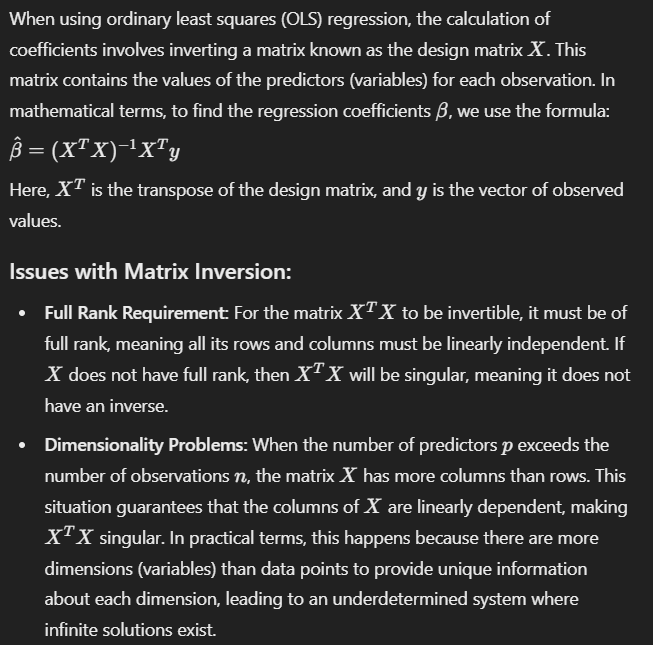

    * Overfitting: With more parameters than observations, the model can perfectly fit the training data, capturing noise rather than the underlying signal. This leads to poor generalization on new data.

In [1]:
# Code Example for Multicollinerity
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n = 100
X1 = np.random.normal(0, 1, n)
X2 = X1 + np.random.normal(0, 0.1, n)  # X2 is highly correlated with X1
y = 2 * X1 + 3 * X2 + np.random.normal(0, 1, n)

# Create DataFrame
df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

# Fit OLS regression
X = sm.add_constant(df[['X1', 'X2']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     952.5
Date:                Sat, 04 Jan 2025   Prob (F-statistic):           1.73e-64
Time:                        06:03:29   Log-Likelihood:                -147.62
No. Observations:                 100   AIC:                             301.2
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0886      0.108      0.819      0.4

## Filter Methods
Predictors included in a model must be
- Relevant - Related to the outcome variable
- Non-redundant - Not related to other predictors

**Methods**
* Bivariate Filter
* Multiariate Filter - VIF

### Bivariate Filter
The Bivariate Filter is a feature selection method used in data preprocessing to identify and retain the most relevant variables for modeling. This method examines the pairwise correlation between variables to assess the relationships and decide which features might be important for predicting the outcome.

* Relevant
    - High Bivariate Correlation with Outcome: Features that show a high correlation with the outcome variable are considered relevant because they potentially have a strong linear relationship with the target, suggesting a significant impact on the model's prediction.
* Non-redundant
    - Low Bivariate Correlation Among Predictors: To avoid redundancy and multicollinearity, features that are less correlated with each other are preferred. This helps in reducing the complexity of the model and improves generalizability by minimizing the risk of overfitting.
* Correlation Hearmap: A visual tool used to quickly assess the strength and direction of the relationships between each pair of variables. The heatmap helps in identifying which features are strongly linked to the outcome and which are redundant.

**Pearson Correlation Coefficient**
- Pearson Correlation Coefficient is commonly used to measure the linear relationship between two variables. The coefficient ranges from -1 to 1, where:
    * 1 indicates a perfect positive linear relationship,
    * -1 indicates a perfect negative linear relationship,
    * 0 indicates no linear relationship.
**Formula**

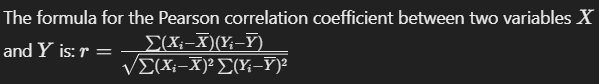

- This formula effectively measures how much the deviations of one variable predict the deviations of another, normalized by the product of the standard deviations of these variables.

**Note on the difference between correlation coefficient (r) and Beta Coefficient**

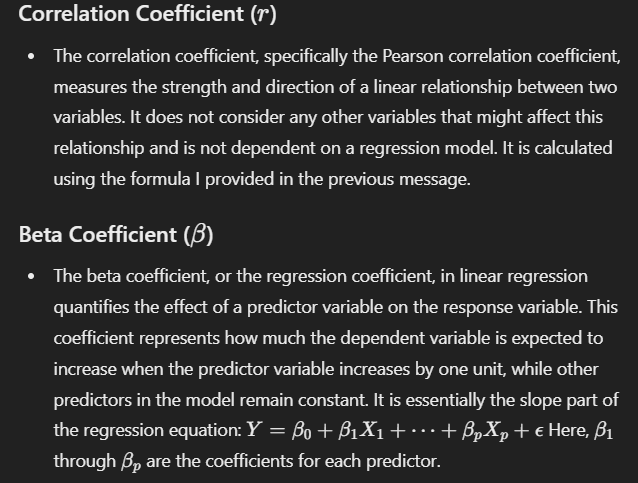

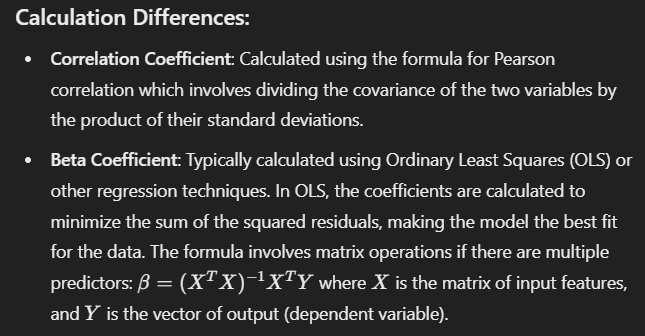

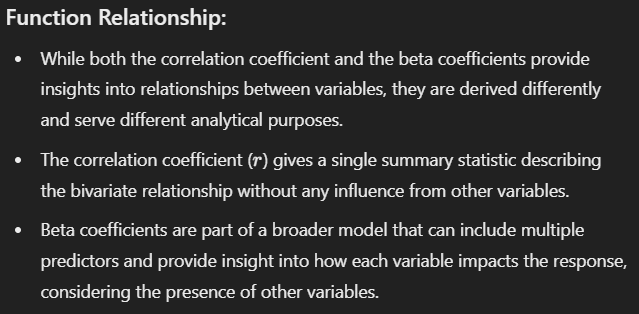


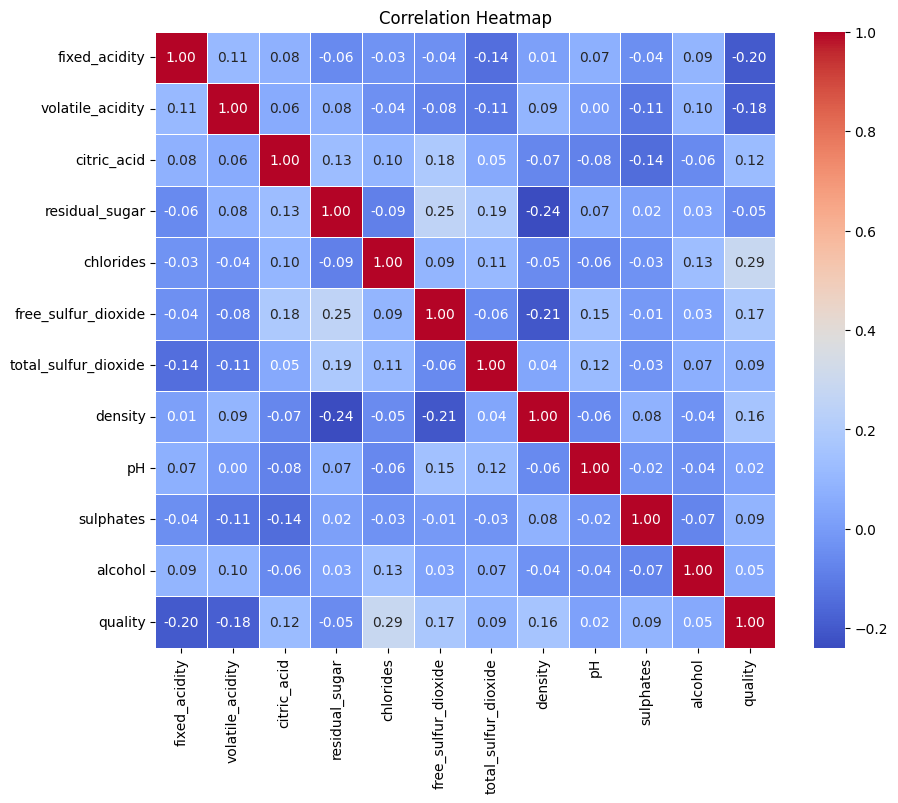

In [3]:
# Code Example for the Heat Map - which quality is the outcome variable
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
data = pd.DataFrame({
    'fixed_acidity': np.random.normal(0, 1, 100),
    'volatile_acidity': np.random.normal(0, 1, 100),
    'citric_acid': np.random.normal(0, 1, 100),
    'residual_sugar': np.random.normal(0, 1, 100),
    'chlorides': np.random.normal(0, 1, 100),
    'free_sulfur_dioxide': np.random.normal(0, 1, 100),
    'total_sulfur_dioxide': np.random.normal(0, 1, 100),
    'density': np.random.normal(0, 1, 100),
    'pH': np.random.normal(0, 1, 100),
    'sulphates': np.random.normal(0, 1, 100),
    'alcohol': np.random.normal(0, 1, 100),
    'quality': np.random.normal(0, 1, 100)  # This is the outcome variable
})

# Calculate the correlation matrix
corr_matrix = data.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

### Multivariate Filter
Examine relevance and redundancy of all predictors together. Often, what is true in pairwise relationships may not be found when all variables are considered together. 

- Relevance
    * Significance of Regression Coefficients: In multiple regression models, the relevance of predictors is often gauged by the significance of their regression coefficients. If a predictor has a statistically significant coefficient, it implies a meaningful contribution to the model in predicting the response variable.
    * Large Sample Sizes: In large datasets, even minor effects may become statistically significant due to increased power to detect effects. This doesn't necessarily mean that every significant predictor is truly important for your model. Statistically significant results in large samples might be due to the sample size rather than the effect size.

- Non-redundant
    * Multicollinearity: This refers to situations where predictors are not just correlated pairwise, but one predictor is a linear combination of one or more other predictors. High multicollinearity among variables can distort the estimation of regression coefficients, making them unstable and difficult to interpret.
    * Variance Inflation Factor (VIF): VIF is a measure that quantifies the level of multicollinearity in an ordinary least squares regression analysis. It provides an index that measures how much the variance of an estimated regression coefficient increases if your predictors are correlated. If no factors are correlated, the VIFs will be 1.

**How VIF is Calculated**

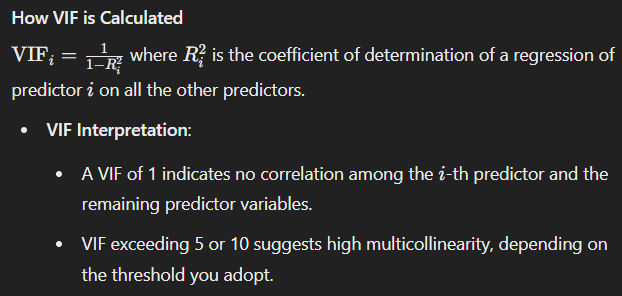

**Explination of coefficient of determination**

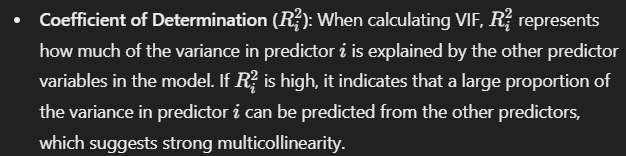

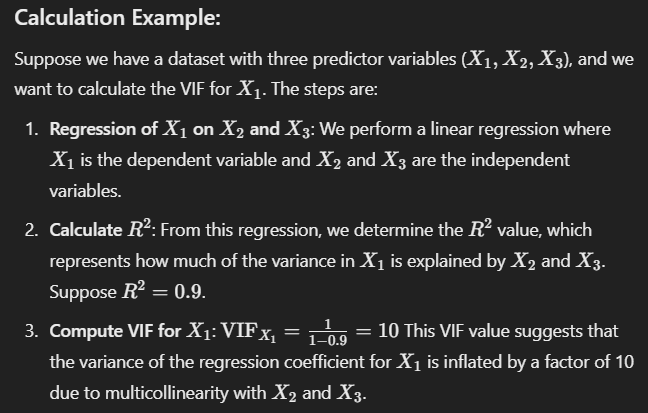

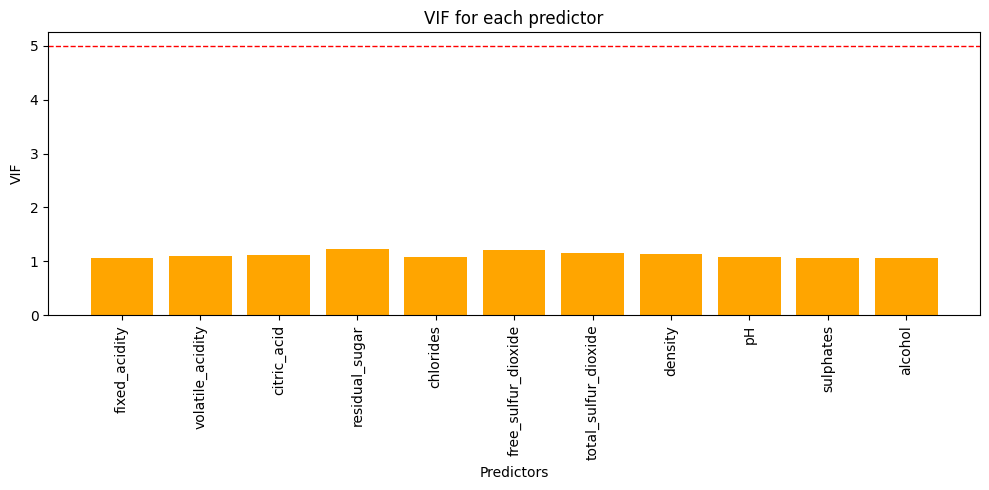

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Generate synthetic data
np.random.seed(0)
data = pd.DataFrame({
    'fixed_acidity': np.random.normal(0, 1, 100),
    'volatile_acidity': np.random.normal(0, 1, 100),
    'citric_acid': np.random.normal(0, 1, 100),
    'residual_sugar': np.random.normal(0, 1, 100),
    'chlorides': np.random.normal(0, 1, 100),
    'free_sulfur_dioxide': np.random.normal(0, 1, 100),
    'total_sulfur_dioxide': np.random.normal(0, 1, 100),
    'density': np.random.normal(0, 1, 100),
    'pH': np.random.normal(0, 1, 100),
    'sulphates': np.random.normal(0, 1, 100),
    'alcohol': np.random.normal(0, 1, 100)
})

# Add a constant term for intercept
data = add_constant(data)

# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = data.columns
vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

# Remove the entry for the constant term
vif_data = vif_data[vif_data['feature'] != 'const']

# Plotting the VIF values
plt.figure(figsize=(10, 5))
plt.bar(vif_data['feature'], vif_data['VIF'], color='orange')
plt.xlabel('Predictors')
plt.ylabel('VIF')
plt.title('VIF for each predictor')
plt.axhline(5, color='r', linestyle='dashed', linewidth=1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Subset Selection
* Best Sebset Selection
* Forward Selection
* Backward Selection
* Stepwise Selection

**Evaluation Criteria**
- Training set error will decrease as more variables are added, but the test error may not. 
- Therefore, training set RSS (residual sum of squares) and training set R2 cannot be used to select from among a set of models with different number of variables. 
- In order to select the best model with respect to test error, we need to estimate the test error. There are two approaches to this 
    * Indirectly estimate test error by making an adjustment to the training error to account for bias due to overfitting.   
    * Directly estimate test error using a validation set approach or cross-validation. (will be discussed in a later topic)

**Indirect Estimates of Test Error**
- apply a penalty to the residual sum of squares for the number of predictors used
- All these indices apply a penalty to the residual sum of squares for the number of predictors used. 
    1. Adjusted R-squared

    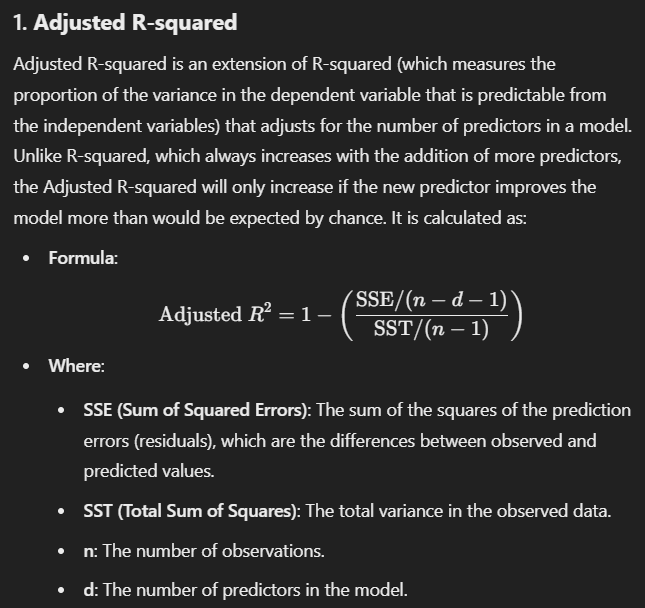

    2. Akaike Information Criterion (AIC)

    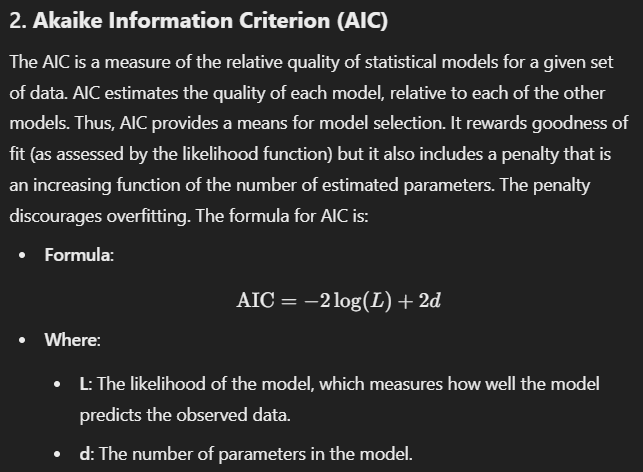

    3. Bayesian Information Criterion

    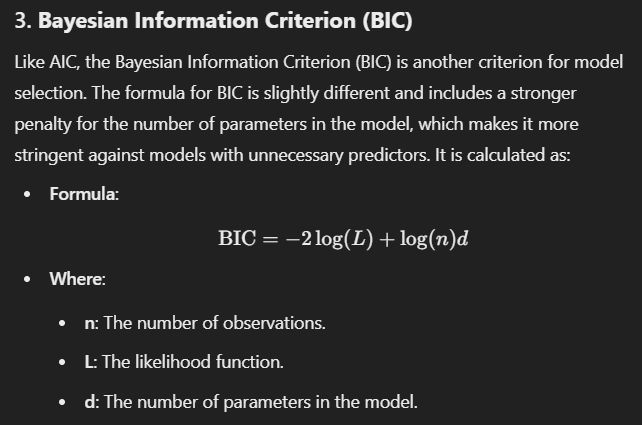

    4. Mallows' Cp

    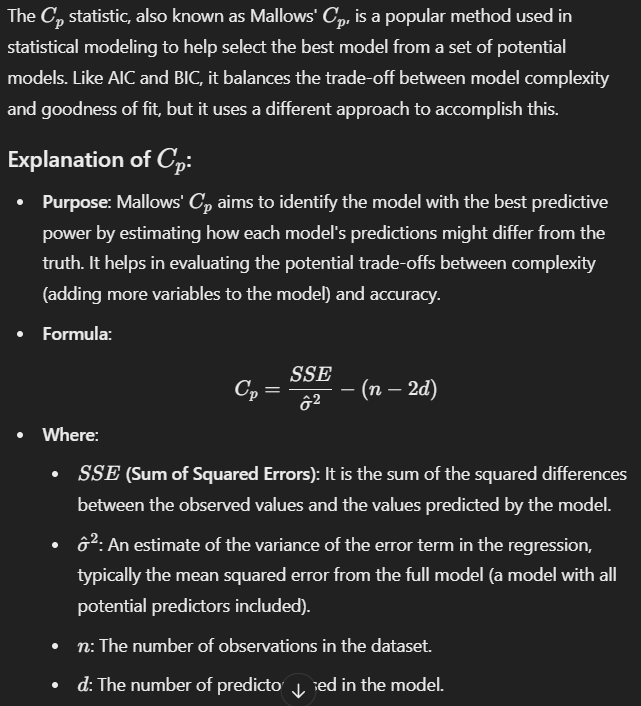

    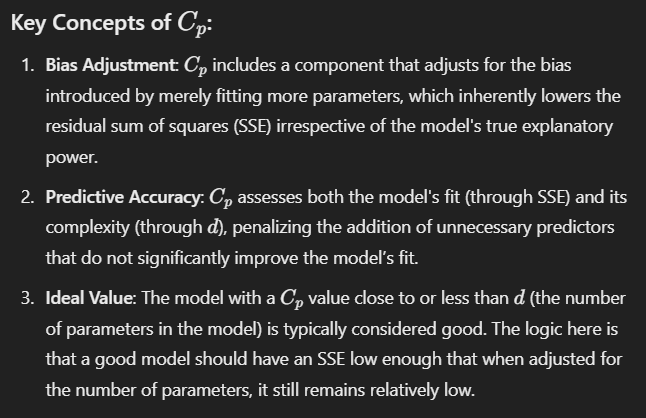

- These metrics are particularly useful when comparing models that have a different number of predictors. They help in identifying a model that balances between model complexity and model performance. While AIC is more biased towards selecting more complex models, BIC tends to select simpler models because of its heavier penalty on model complexity.

### Best Subset Selection
**Steps**
1.	Consider all possible subsets of p predictors. 
2.	Fit a model with each subset. 
3.	Pick the best performing model

**Problem**
- Computational Complexity: The number of possible models that need to be evaluated grows exponentially with 𝑝. Specifically, the number of models is 2𝑝 because each predictor can either be included in or excluded from a model. This exponential growth is captured by the sum:

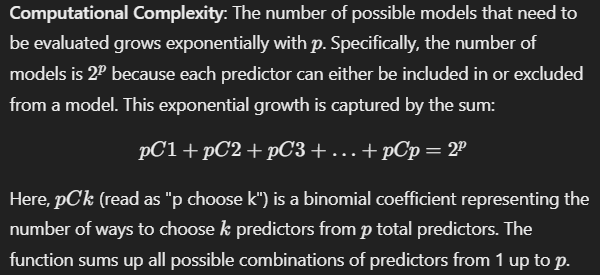

- Overfitting Risk: With a large number of predictors (𝑝), there's a higher likelihood of constructing a model that fits the training data too well, incorporating noise as signal (overfitting). These models might show excellent performance on training data due to being overly complex, but they generally perform poorly on unseen, future data. This is because the model learns the idiosyncrasies of the training data rather than the underlying pattern that generalizes well.

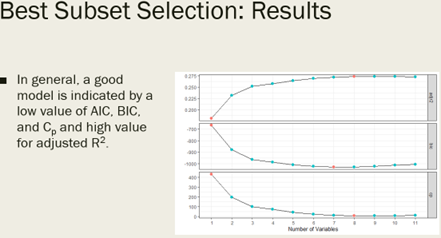

### Forward Selection - Handle p > n
**Steps**
1.	Forward selection method begins with a model containing no predictors and then adds predictors to the model, one at a time
2.	Variables are added in order of the marginal improvement to the model. At each stage, the variable that gives the largest marginal improvement is added.
3.	Addition of variables stops when marginal improvement is not significant

- Compared to Best Subsets method, this method is computationally efficient. For p predictors, number of models estimated is: 1 + p(p+1)/2
- **Can Handle situation which number of predictors (p) is greater than the size of the training sample (n)**

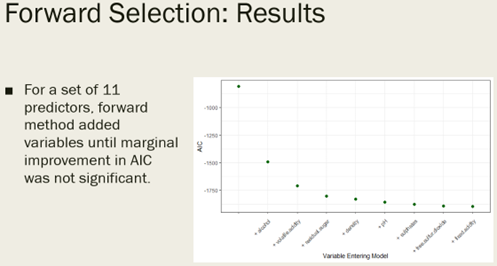

### Backward Selection
**Steps**
1.	Backward selection method begins with a model containing all predictors and then removes predictors from the model, one at a time
2.	Variables are removed iteratively with the least useful predictor being dropped first.
3.	Removal of variables stops when elimination of a predictor significantly worsens the model.

- Backward selection is just forward selection in reverse. Like Forward selection, For p predictors, number of models estimated is: 1 + p(p+1)/2
- **However, one limitation of backward selection is that it cannot be used for models where p > n. On the other hand, forward selection can handle such high-dimensional models.**

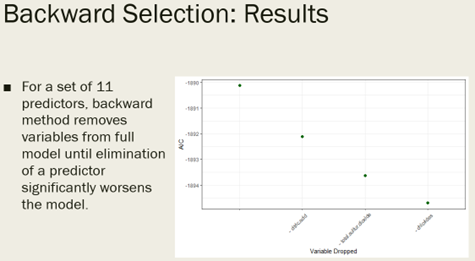

### Stepwise Selection
* Forward and Backward methods are run simultaneously
* Predictors may be added or removed at each stage until the optimal model is reached
* Stepwise method attempts to more closely mimic benefits of best subsets while retaining the computational advantages of forward and backward selection methods.

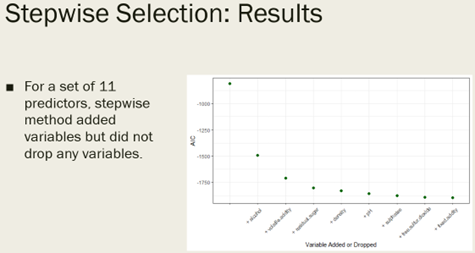

## Shrinkage
- Shrinkage methods constrain or regularize coefficient estimates, or equivalently, shrink the coefficient estimates towards zero. They do so by adding a shrinkage penalty to punish a model for complexity.
- While OLS minimizes the residual sum of squares (sse) to estimate coefficients, shrinkage methods minimize the sum of squared errors (SSE), also known as residual sum of squares and a shrinkage penalty. 
    * OLS: min(SSE)
    * Shrinkage methods: min(SSE + λ* shrinkage penalty)

**Ridge Regression**
- **Underlying Theory**: Ridge regression adds a penalty equal to the square of the magnitude of coefficients to the loss function. This method penalizes the sum of squared coefficients, which is known as the L2 penalty. The primary goal of Ridge regression is to shrink the coefficients, thus reducing model complexity and multicollinearity.
- Shrinking coefficient estimates can significantly reduce their variance and lead to better fit. However, ***ridge regression will include all predictors in the model***. 

**Calculation Function**

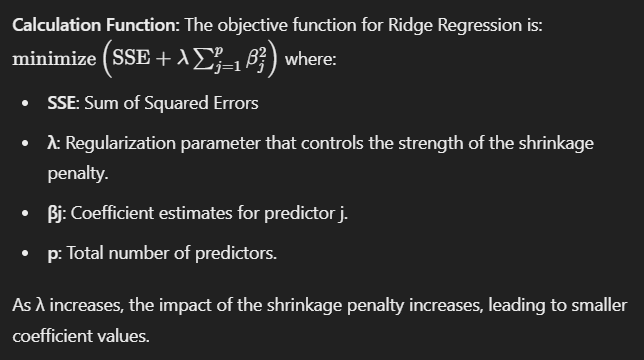


**Lasso - can accept p>n**
- **Underlying Theory**: Lasso (Least Absolute Shrinkage and Selection Operator) is similar to Ridge but it uses an L1 penalty (the sum of the absolute values of coefficients). This difference allows Lasso not only to shrink coefficients but also to set some coefficients to zero entirely, thus performing feature selection.
    * The extent of shrinkage penalty depends on the value of the tuning parameter, λ.  
    * When λ = 0, the penalty has no effect and Lasso will produce least square estimates. 
    * As λ gets larger, the penalty grows and coefficient estimates are forced to zero. 
    * The optimal value of λ is typically determined by examining cross-validation error of a set of λs using k-fold cross-validation.

**Calculation Function**

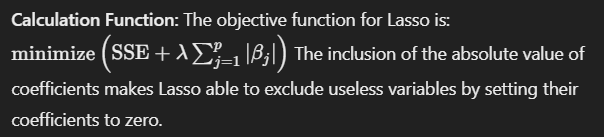

**Ridge Regression VS Lasso**
- The shrinkage penalty in Ridge regression suppresses all coefficients, on the other hand, the penalty in Lasso has the effect of forcing some, not all, coefficient estimates to be exactly zero. By forcing only some coefficient estimate to zero, Lasso in essence performs feature selection.

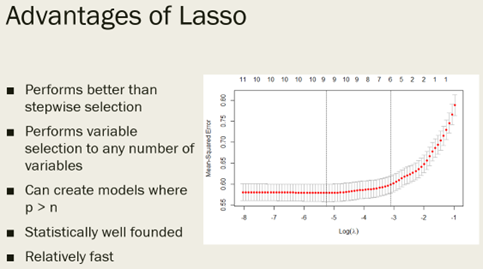

## Dimension Reduction

**Principal Components Regression (Principal Components Analysis)**
- PCA is a statistical technique used for dimensionality reduction while preserving as much variability in the data as possible. It works by identifying directions, called principal components, along which the variation of the data is maximized. These principal components are orthogonal to each other and are linear combinations of the original predictors.
- **Process**: PCA starts by computing the covariance matrix of the predictors to understand how the variables vary together. It then computes the eigenvalues and eigenvectors of this covariance matrix. The eigenvectors define the directions of the new feature space, and the eigenvalues determine their magnitude—in other words, the eigenvalues explain the variance of the data along the new feature axes.
- **Dimentsion Reduction**: Typically, only a subset of principal components is selected: those that capture the most significant amount of variance (often using a scree plot or a specified percentage of total variance, e.g., 70%). This results in reducing the number of variables significantly while retaining the most informative parts of the data.
    * PCA generates linear combinations of original p predictors
    * A matrix with p variables will generate p components such that the first component captures the most variance, followed by the second, and so on. 
    * Generally, the number of components to be retained is based on eigen-value of extracted components, a scree plot, and capturing a certain amount of variance (e.g., 70%). 
    * The reduced number of components are used to predict the outcome instead of the original set of predictors.

**Partial Least Squares (PLS)**
- Partial Least Squares (PLS) is similar to PCA but incorporates information about the output variable (response) when performing dimension reduction. Unlike PCA, which is unsupervised and only considers the predictor data, PLS is supervised and tries to find the components that not only capture the most variance but also will best predict the response variable.
- **Process**: PLS constructs new features by projecting the original features onto the directions that have the highest covariance with the response, thereby preserving essential predictive information.
- **Supervised Dimension Reduction**: By considering the response variable during the component construction, PLS is particularly useful when predictors are many and highly collinear, and the goal is predictive modeling.
    * Like PCR, PLS is a dimension reduction method, which first identifies a new set of features Z1, . . . , ZM that are linear combinations of the original features, and then fits a linear model via OLS using these M new features.
    * But unlike PCR, PLS identifies these new features in a supervised way – that is, it makes use of the response Y in order to identify new features that not only approximate the old features well, but also that are related to the response.
    * Roughly speaking, the PLS approach attempts to find directions that help explain both the response and the predictors.


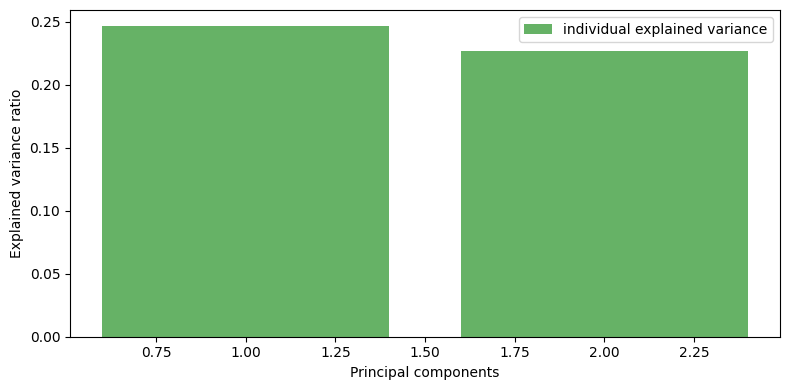

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic data
np.random.seed(0)
data = np.random.randn(100, 5)  # 100 samples and 5 features

# Standardizing the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Applying PCA
pca = PCA(n_components=2)  # reduce to 2 components
components = pca.fit_transform(data_scaled)

# Plotting the explained variance
plt.figure(figsize=(8,4))
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.6, color='g', label='individual explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout() 
plt.show()


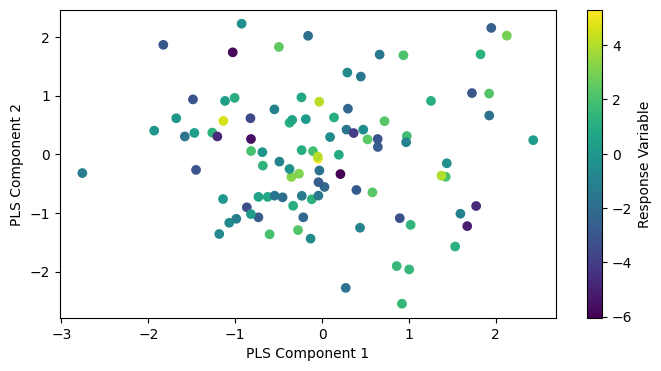

In [10]:
# Code Example for PLS
from sklearn.cross_decomposition import PLSRegression

# Generating synthetic data
Y = data[:, 0] + 2 * data[:, 1] + np.random.randn(100)  # Create a response variable
X = data[:, 2:]  # Use remaining variables as predictors

# Applying PLS
pls = PLSRegression(n_components=2)
pls.fit(X, Y)
X_pls = pls.transform(X)

# Visualizing the results
plt.figure(figsize=(8,4))
plt.scatter(X_pls[:, 0], X_pls[:, 1], c=Y, cmap='viridis')
plt.xlabel('PLS Component 1')
plt.ylabel('PLS Component 2')
plt.colorbar(label='Response Variable')
plt.show()